# 01. Exploración de Datos (EDA)

En esta etapa, nos enfocaremos en entender la naturaleza del dataset de *California Housing*.
**Objetivo:** Obtener un entendimiento de los datos, de la industria, identificar anomalías, rangos, y relaciones clave.

### Instrucciones Generales:
1. **Carga los datos:** Lee el archivo `.csv` proveniente de la carpeta `data/raw/`
2. **Inspección:** Analisis exploratorio de datos, estructura, problemas de calidad: consistencia, sensibilidad, precision y completitud.
3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.
4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.
5. **Correlaciones:** Calcula la matriz de correlación (usando `.corr()`) de todas las variables frente a `median_house_value` para encontrar las más prometedoras y graficos de dispercion entre las variables.
6. **Concluciones**: Redactar todos los hallazgos con un lenguaje de negocio y comunicativo.

In [ ]:
# Escribe tu código aquí para explorar el dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Apuntar al root del proyecto para importar src/
# Path().resolve() apunta a notebooks/ — subimos un nivel para llegar a la raíz
PROJECT_ROOT = Path().resolve().parent
# Verificar que encontramos la raíz correcta (debe contener src/ y data/)
assert (PROJECT_ROOT / 'src').exists(), (
    f'PROJECT_ROOT incorrecto: {PROJECT_ROOT}\n'
    f'Asegúrate de abrir el notebook desde notebooks/ dentro del proyecto'
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORTS_DIR = PROJECT_ROOT / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 15)

print('Setup completo')
print(f'PROJECT_ROOT : {PROJECT_ROOT}')

Setup completo
PROJECT_ROOT : C:\Proyecto\ds-ml-project-template


In [11]:
import tarfile
import urllib.request

# ── Rutas ────────────────────────────────────────────────────────────────────
# El .tgz de Ageron extrae en una subcarpeta housing/housing.csv
HOUSING_URL  = 'https://github.com/ageron/data/raw/main/housing.tgz'
HOUSING_PATH = PROJECT_ROOT / 'data' / 'raw'
TGZ_PATH     = HOUSING_PATH / 'housing.tgz'
CSV_PATH     = HOUSING_PATH / 'housing' / 'housing.csv'  # subcarpeta housing/

print(f'Raíz del proyecto : {PROJECT_ROOT}')
print(f'CSV esperado en   : {CSV_PATH}')

# ── Descarga y extracción (solo si el CSV no existe aún) ─────────────────────
if not CSV_PATH.exists():
    HOUSING_PATH.mkdir(parents=True, exist_ok=True)

    print(f'Descargando desde: {HOUSING_URL} ...')
    urllib.request.urlretrieve(HOUSING_URL, TGZ_PATH)
    print(f'Descargado: {TGZ_PATH.name} ({TGZ_PATH.stat().st_size / 1024:.0f} KB)')

    print('Extrayendo...')
    with tarfile.open(TGZ_PATH) as tar:
        tar.extractall(path=HOUSING_PATH)

    print(f'✅ CSV disponible en: {CSV_PATH}')
else:
    print(f'✅ CSV ya existe — omitiendo descarga')

# ── Carga ─────────────────────────────────────────────────────────────────────
housing = pd.read_csv(CSV_PATH)

print(f'\nDataset cargado : {housing.shape[0]:,} filas x {housing.shape[1]} columnas')
print(f'Columnas        : {list(housing.columns)}')
print(f'NaN             : {housing.isnull().sum()[housing.isnull().sum() > 0].to_dict()}')


Raíz del proyecto : C:\Proyecto\ds-ml-project-template
CSV esperado en   : C:\Proyecto\ds-ml-project-template\data\raw\housing\housing.csv
Descargando desde: https://github.com/ageron/data/raw/main/housing.tgz ...
Descargado: housing.tgz (439 KB)
Extrayendo...
✅ CSV disponible en: C:\Proyecto\ds-ml-project-template\data\raw\housing\housing.csv

Dataset cargado : 20,640 filas x 10 columnas
Columnas        : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']
NaN             : {'total_bedrooms': 207}


In [12]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.2300,37.8800,41.0000,880.0000,129.0000,322.0000,126.0000,8.3252,452600.0000,NEAR BAY
1,-122.2200,37.8600,21.0000,7099.0000,1106.0000,2401.0000,1138.0000,8.3014,358500.0000,NEAR BAY
2,-122.2400,37.8500,52.0000,1467.0000,190.0000,496.0000,177.0000,7.2574,352100.0000,NEAR BAY
3,-122.2500,37.8500,52.0000,1274.0000,235.0000,558.0000,219.0000,5.6431,341300.0000,NEAR BAY
4,-122.2500,37.8500,52.0000,1627.0000,280.0000,565.0000,259.0000,3.8462,342200.0000,NEAR BAY


In [13]:
# Tipos de dato y memoria
print('TIPOS DE DATO')
print('-' * 42)
for col, dtype in housing.dtypes.items():
    print(f'  {col:<25} {str(dtype)}')

mem_mb = housing.memory_usage(deep=True).sum() / 1024 / 1024
print(f'\nUso de memoria: {mem_mb:.2f} MB')

TIPOS DE DATO
------------------------------------------
  longitude                 float64
  latitude                  float64
  housing_median_age        float64
  total_rooms               float64
  total_bedrooms            float64
  population                float64
  households                float64
  median_income             float64
  median_house_value        float64
  ocean_proximity           str

Uso de memoria: 2.54 MB


In [14]:
# Estadísticas descriptivas completas
housing.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
longitude,20640.0000,-119.5697,2.0035,-124.3500,-123.2200,-122.4700,-121.8000,-118.4900,-118.0100,-117.0800,-116.2900,-114.3100
latitude,20640.0000,35.6319,2.1360,32.5400,32.6800,32.8200,33.9300,34.2600,37.7100,38.9600,40.6261,41.9500
housing_median_age,20640.0000,28.6395,12.5856,1.0000,4.0000,8.0000,18.0000,29.0000,37.0000,52.0000,52.0000,52.0000
total_rooms,20640.0000,2635.7631,2181.6153,2.0000,164.0000,620.9500,1447.7500,2127.0000,3148.0000,6213.2000,11212.1100,39320.0000
total_bedrooms,20433.0000,537.8706,421.3851,1.0000,36.0000,137.0000,296.0000,435.0000,647.0000,1275.4000,2221.3600,6445.0000
population,20640.0000,1425.4767,1132.4621,3.0000,88.0000,348.0000,787.0000,1166.0000,1725.0000,3288.0000,5805.8300,35682.0000
households,20640.0000,499.5397,382.3298,1.0000,31.0000,125.0000,280.0000,409.0000,605.0000,1162.0000,1982.6600,6082.0000
median_income,20640.0000,3.8707,1.8998,0.4999,1.0696,1.6006,2.5634,3.5348,4.7432,7.3003,10.5965,15.0001
median_house_value,20640.0000,206855.8169,115395.6159,14999.0000,50000.0000,66200.0000,119600.0000,179700.0000,264725.0000,489810.0000,500001.0000,500001.0000


In [15]:
# COMPLETITUD: valores faltantes
print('VALORES FALTANTES')
print('-' * 50)

missing = pd.DataFrame({
    'N faltantes' : housing.isnull().sum(),
    '% faltantes' : (housing.isnull().mean() * 100).round(2),
    'Dtype'       : housing.dtypes,
})
missing_cols = missing[missing['N faltantes'] > 0]

if missing_cols.empty:
    print('No hay valores faltantes.')
else:
    display(missing_cols)
    print('Accion requerida en Fase 2: imputacion de total_bedrooms')

VALORES FALTANTES
--------------------------------------------------


,N faltantes,% faltantes,Dtype
total_bedrooms,207,1.0000,float64


Accion requerida en Fase 2: imputacion de total_bedrooms


In [16]:
# CONSISTENCIA: duplicados y categorías
n_dup = housing.duplicated().sum()
print(f'Filas duplicadas: {n_dup}')

print('\nocean_proximity - categorias y frecuencias:')
ocp = housing['ocean_proximity'].value_counts()
for cat, cnt in ocp.items():
    bar = '|' * (cnt // 300)
    print(f'  {cat:<15} {cnt:>6,}  {bar}')

Filas duplicadas: 0

ocean_proximity - categorias y frecuencias:
  <1H OCEAN        9,136  ||||||||||||||||||||||||||||||
  INLAND           6,551  |||||||||||||||||||||
  NEAR OCEAN       2,658  ||||||||
  NEAR BAY         2,290  |||||||
  ISLAND               5  


In [17]:
# PRECISION: outliers por IQR
print(f'{"Variable":<25} {"Q1":>8} {"Q3":>8} {"Lim.Sup":>10} {"Outliers":>10} {"% total":>8}')
print('-' * 72)

for col in housing.select_dtypes(include=np.number).columns:
    Q1  = housing[col].quantile(0.25)
    Q3  = housing[col].quantile(0.75)
    IQR = Q3 - Q1
    lim = Q3 + 1.5 * IQR
    n   = (housing[col] > lim).sum()
    pct = n / len(housing) * 100
    flag = '  <-- revisar' if pct > 3 else ''
    print(f'  {col:<23} {Q1:>8.1f} {Q3:>8.1f} {lim:>10.1f} {n:>10,} {pct:>7.1f}%{flag}')

Variable                        Q1       Q3    Lim.Sup   Outliers  % total
------------------------------------------------------------------------
  longitude                 -121.8   -118.0     -112.3          0     0.0%
  latitude                    33.9     37.7       43.4          0     0.0%
  housing_median_age          18.0     37.0       65.5          0     0.0%
  total_rooms               1447.8   3148.0     5698.4      1,287     6.2%  <-- revisar
  total_bedrooms             296.0    647.0     1173.5      1,271     6.2%  <-- revisar
  population                 787.0   1725.0     3132.0      1,196     5.8%  <-- revisar
  households                 280.0    605.0     1092.5      1,220     5.9%  <-- revisar
  median_income                2.6      4.7        8.0        681     3.3%  <-- revisar
  median_house_value      119600.0 264725.0   482412.5      1,071     5.2%  <-- revisar


In [18]:
# SENSIBILIDAD: cap en el target
cap_val = housing['median_house_value'].max()
n_cap   = (housing['median_house_value'] == cap_val).sum()
print(f'Valor maximo de median_house_value : ${cap_val:,.0f}')
print(f'Registros en ese valor (cap)       : {n_cap:,} ({n_cap/len(housing)*100:.1f}%)')
print()
print('El dataset original censura precios superiores a $500,001.')
print('Estos registros deben tratarse con cuidado en el modelado.')

Valor maximo de median_house_value : $500,001
Registros en ese valor (cap)       : 965 (4.7%)

El dataset original censura precios superiores a $500,001.
Estos registros deben tratarse con cuidado en el modelado.


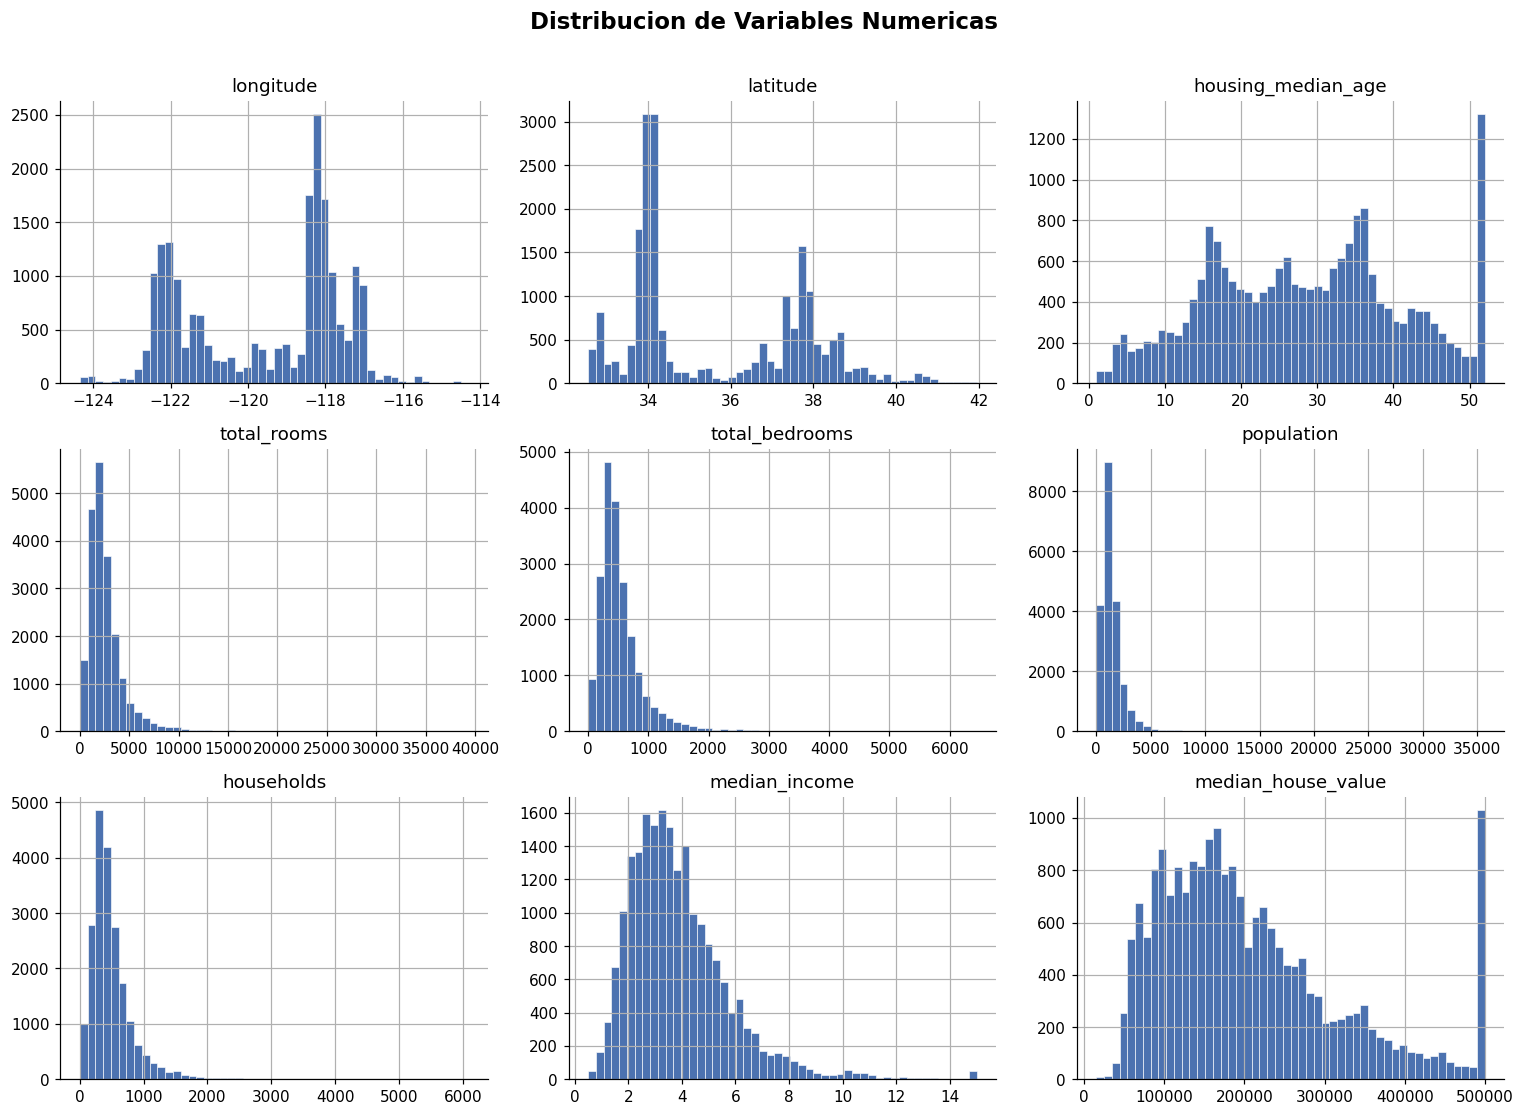

In [19]:
# Histogramas con pandas .hist()
numeric_cols = housing.select_dtypes(include=np.number).columns.tolist()
n_cols_plot  = 3
n_rows_plot  = (len(numeric_cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(14, 10))

housing[numeric_cols].hist(
    bins=50,
    ax=axes.flatten()[:len(numeric_cols)],
    color='#4C72B0',
    edgecolor='white',
    linewidth=0.4,
)

for i in range(len(numeric_cols), len(axes.flatten())):
    axes.flatten()[i].set_visible(False)

fig.suptitle('Distribucion de Variables Numericas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_histogramas.png', bbox_inches='tight', dpi=120)

In [20]:
# Skewness
print('SKEWNESS — |valor| > 1 = sesgo significativo')
print('-' * 55)
skew = housing.select_dtypes(include=np.number).skew().sort_values(ascending=False)
for col, val in skew.items():
    flag = '  <-- log-transform recomendado' if abs(val) > 1 else ''
    print(f'  {col:<25} {val:+.3f}{flag}')

SKEWNESS — |valor| > 1 = sesgo significativo
-------------------------------------------------------
  population                +4.936  <-- log-transform recomendado
  total_rooms               +4.147  <-- log-transform recomendado
  total_bedrooms            +3.460  <-- log-transform recomendado
  households                +3.410  <-- log-transform recomendado
  median_income             +1.647  <-- log-transform recomendado
  median_house_value        +0.978
  latitude                  +0.466
  housing_median_age        +0.060
  longitude                 -0.298


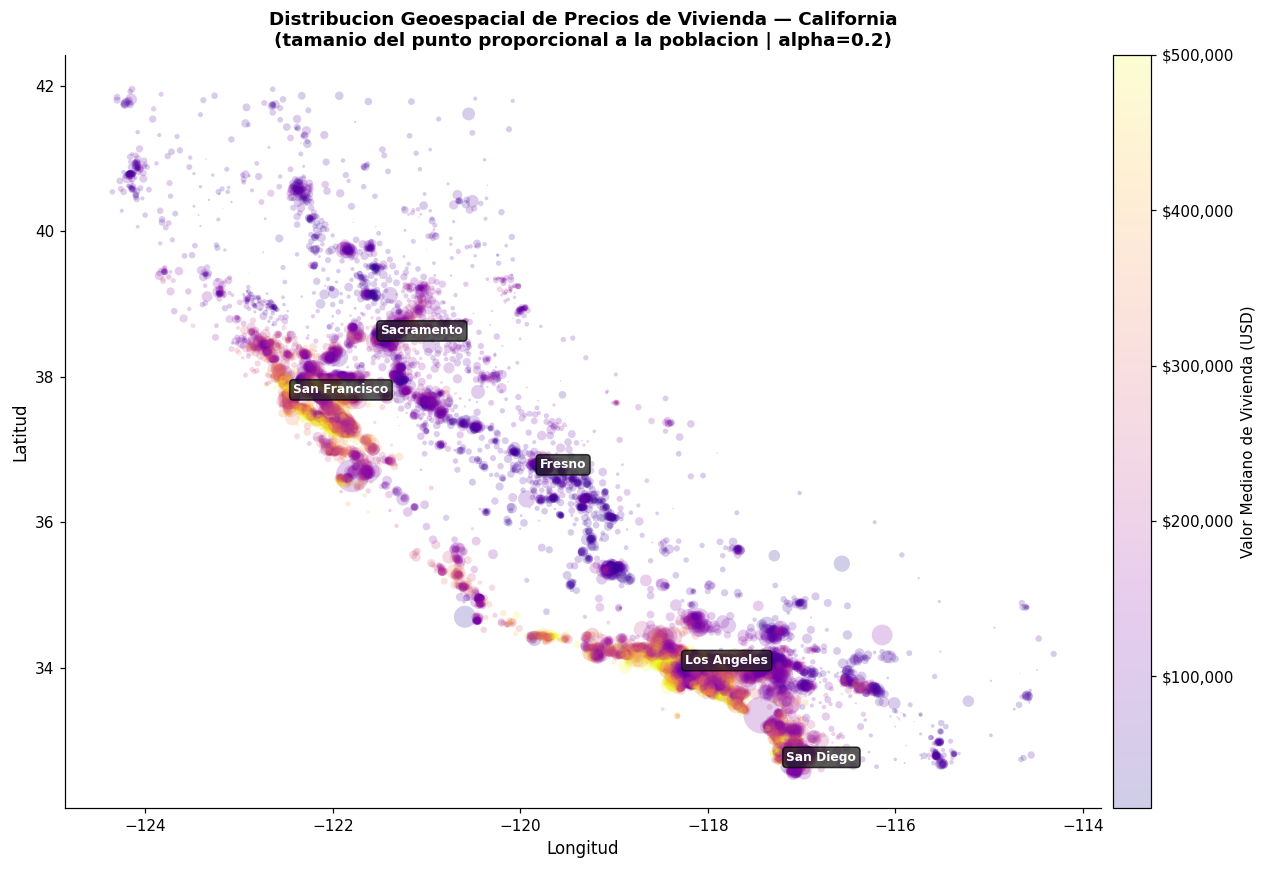

Guardado: reports/eda_mapa_geoespacial.png


In [21]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    x     = housing['longitude'],
    y     = housing['latitude'],
    c     = housing['median_house_value'],
    cmap  = 'plasma',
    alpha = 0.2,
    s     = housing['population'] / 60,
    linewidths = 0,
)

cbar = fig.colorbar(scatter, ax=ax, pad=0.01)
cbar.set_label('Valor Mediano de Vivienda (USD)', fontsize=10)
cbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

# Ciudades de referencia
cities = {
    'San Francisco': (-122.42, 37.77),
    'Los Angeles'  : (-118.24, 34.05),
    'San Diego'    : (-117.16, 32.72),
    'Sacramento'   : (-121.49, 38.58),
    'Fresno'       : (-119.79, 36.74),
}
for city, (lon, lat) in cities.items():
    ax.annotate(
        city, (lon, lat), fontsize=8, fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#222', alpha=0.75),
    )

ax.set_xlabel('Longitud', fontsize=11)
ax.set_ylabel('Latitud',  fontsize=11)
ax.set_title(
    'Distribucion Geoespacial de Precios de Vivienda — California\n'
    '(tamanio del punto proporcional a la poblacion | alpha=0.2)',
    fontsize=12, fontweight='bold',
)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_mapa_geoespacial.png', bbox_inches='tight', dpi=130)
plt.show()
print('Guardado: reports/eda_mapa_geoespacial.png')

In [22]:
# Matriz de correlación completa
corr_matrix = housing.select_dtypes(include=np.number).corr()
corr_matrix.to_csv(REPORTS_DIR / 'eda_correlation_matrix.csv')
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.0000,-0.9247,-0.1082,0.0446,0.0696,0.0998,0.0553,-0.0152,-0.0460
latitude,-0.9247,1.0000,0.0112,-0.0361,-0.0670,-0.1088,-0.0710,-0.0798,-0.1442
housing_median_age,-0.1082,0.0112,1.0000,-0.3613,-0.3205,-0.2962,-0.3029,-0.1190,0.1056
total_rooms,0.0446,-0.0361,-0.3613,1.0000,0.9304,0.8571,0.9185,0.1980,0.1342
total_bedrooms,0.0696,-0.0670,-0.3205,0.9304,1.0000,0.8777,0.9797,-0.0077,0.0497
population,0.0998,-0.1088,-0.2962,0.8571,0.8777,1.0000,0.9072,0.0048,-0.0246
households,0.0553,-0.0710,-0.3029,0.9185,0.9797,0.9072,1.0000,0.0130,0.0658
median_income,-0.0152,-0.0798,-0.1190,0.1980,-0.0077,0.0048,0.0130,1.0000,0.6881
median_house_value,-0.0460,-0.1442,0.1056,0.1342,0.0497,-0.0246,0.0658,0.6881,1.0000


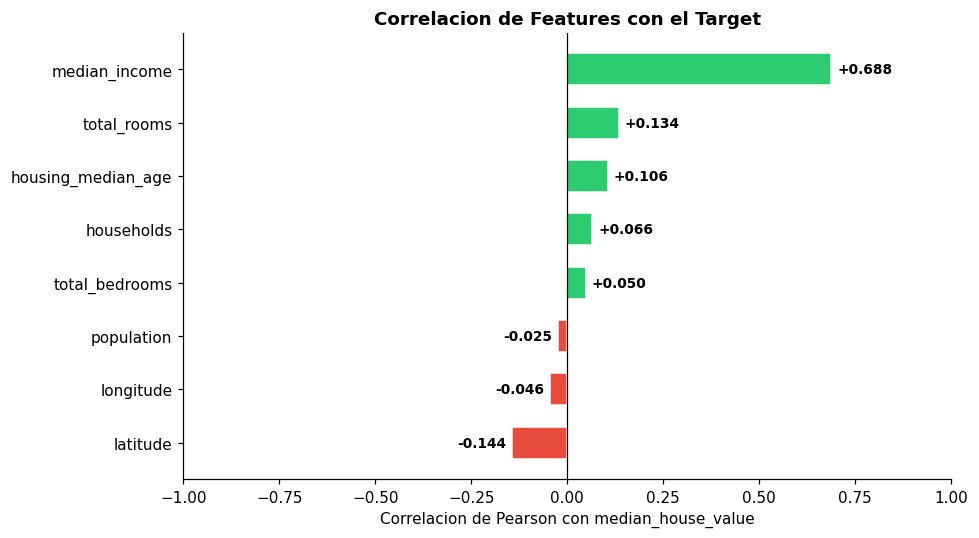


Ranking de correlaciones (por valor absoluto):
  median_income              +0.6881  #################
  latitude                   +0.1442  ###
  total_rooms                +0.1342  ###
  housing_median_age         +0.1056  ##
  households                 +0.0658  #
  total_bedrooms             +0.0497  #
  longitude                  +0.0460  #
  population                 +0.0246  


In [24]:
# Ranking de correlaciones con el target
corr_target = (
    corr_matrix['median_house_value']
    .drop('median_house_value')
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_target]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white', height=0.6)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlacion de Pearson con median_house_value')
ax.set_title('Correlacion de Features con el Target', fontweight='bold')
ax.set_xlim(-1, 1)

for bar, val in zip(bars, corr_target.values):
    ax.text(
        val + (0.015 if val >= 0 else -0.015),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.3f}', va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9, fontweight='bold',
    )

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_correlaciones_target.png', bbox_inches='tight', dpi=120)
plt.show()

print('\nRanking de correlaciones (por valor absoluto):')
for col, val in corr_target.abs().sort_values(ascending=False).items():
    bar = '#' * int(val * 25)
    print(f'  {col:<25}  {val:+.4f}  {bar}')

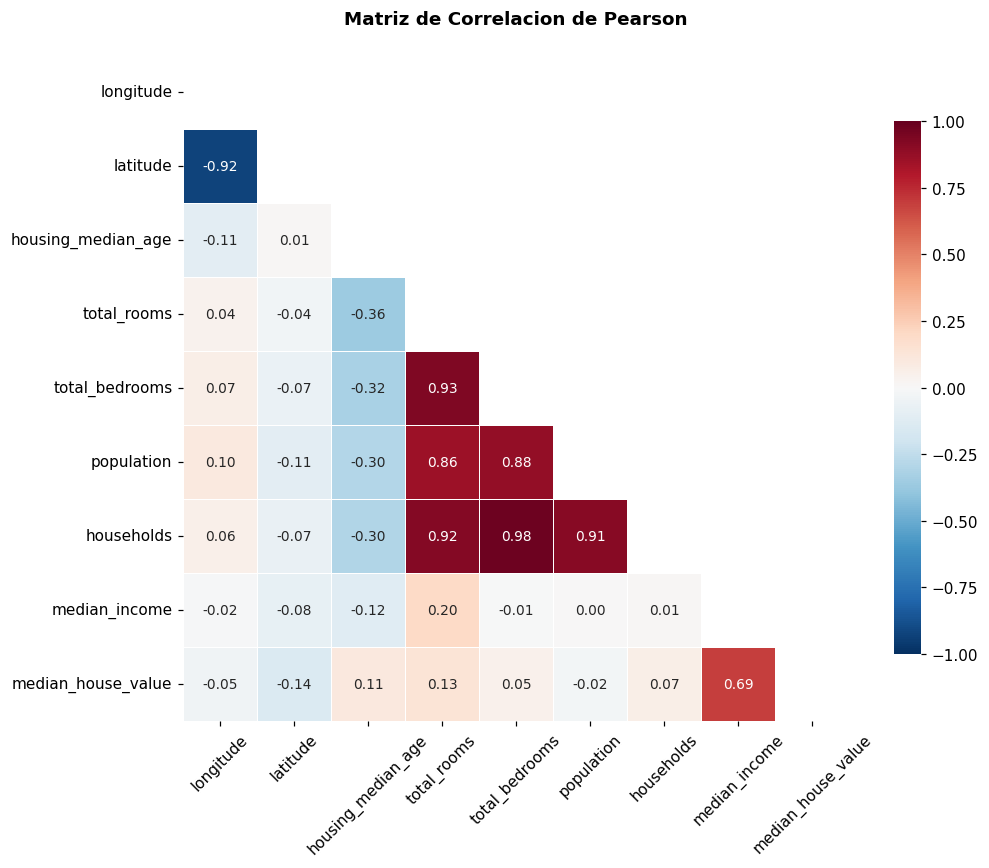

In [25]:
# Heatmap de correlaciones
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    cbar_kws={'shrink': 0.8}, annot_kws={'size': 9},
)
ax.set_title('Matriz de Correlacion de Pearson', fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_heatmap_correlacion.png', bbox_inches='tight', dpi=120)
plt.show()

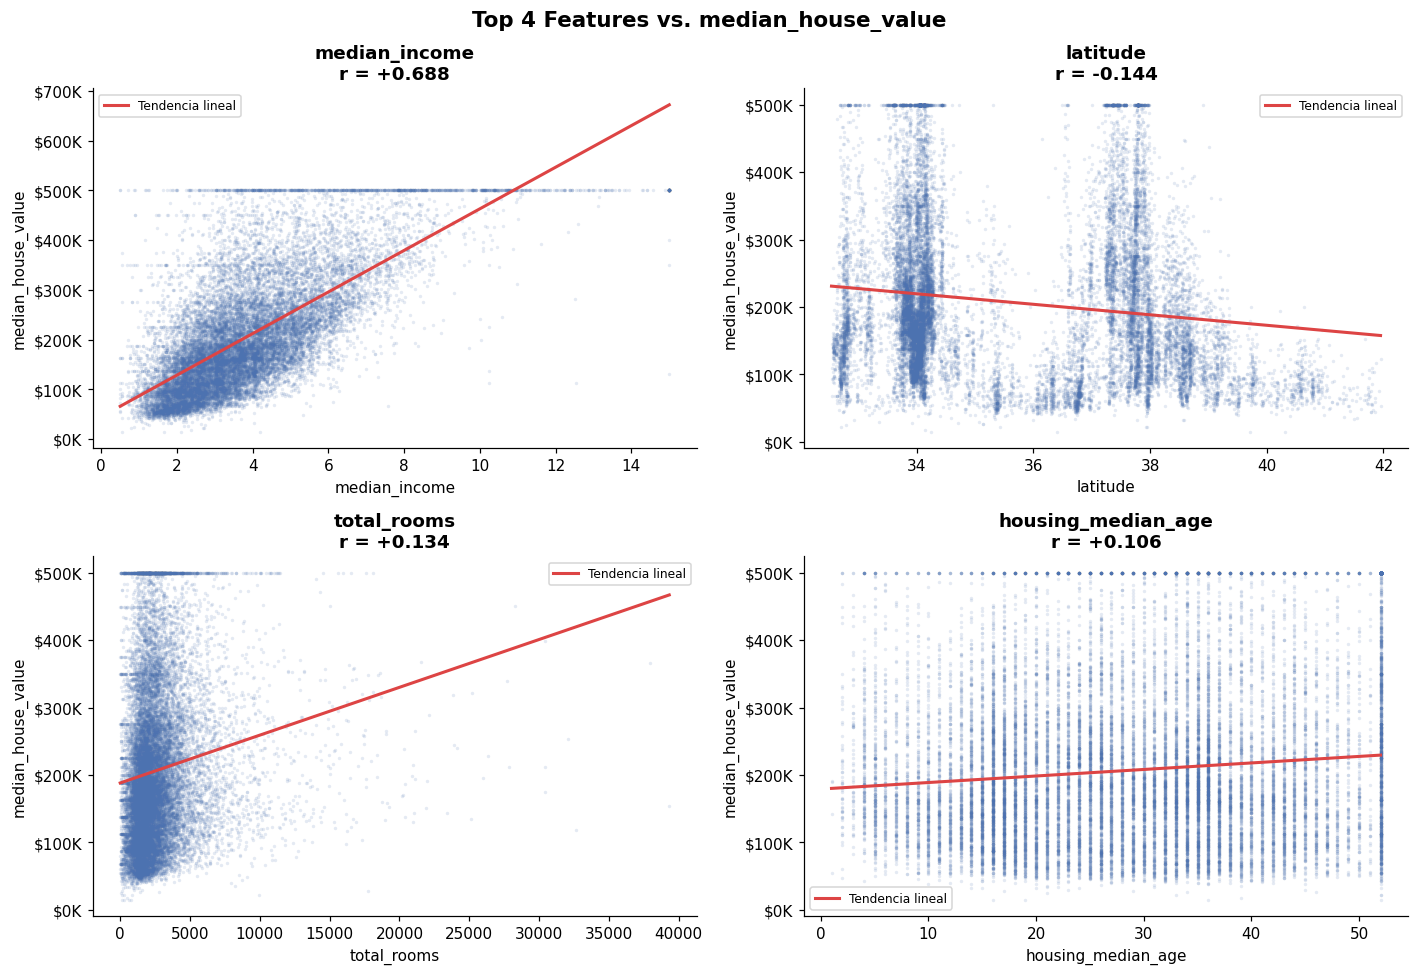

In [26]:
# Scatter plots: top 4 features vs target
top_features = (
    corr_target.abs().sort_values(ascending=False).head(4).index.tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, feat in zip(axes.flatten(), top_features):
    ax.scatter(
        housing[feat], housing['median_house_value'],
        alpha=0.15, s=5, color='#4C72B0', linewidths=0,
    )
    # Línea de tendencia (solo con valores finitos)
    x_data = housing[feat].values
    y_data = housing['median_house_value'].values
    mask_f = np.isfinite(x_data) & np.isfinite(y_data)
    m, b   = np.polyfit(x_data[mask_f], y_data[mask_f], 1)
    x_line = np.linspace(housing[feat].min(), housing[feat].max(), 200)
    ax.plot(x_line, m * x_line + b, color='#DD4444', linewidth=2, label='Tendencia lineal')

    r = corr_matrix.loc[feat, 'median_house_value']
    ax.set_title(f'{feat}\nr = {r:+.3f}', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('median_house_value')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.legend(fontsize=8)

fig.suptitle('Top 4 Features vs. median_house_value', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_scatter_top_features.png', bbox_inches='tight', dpi=120)
plt.show()

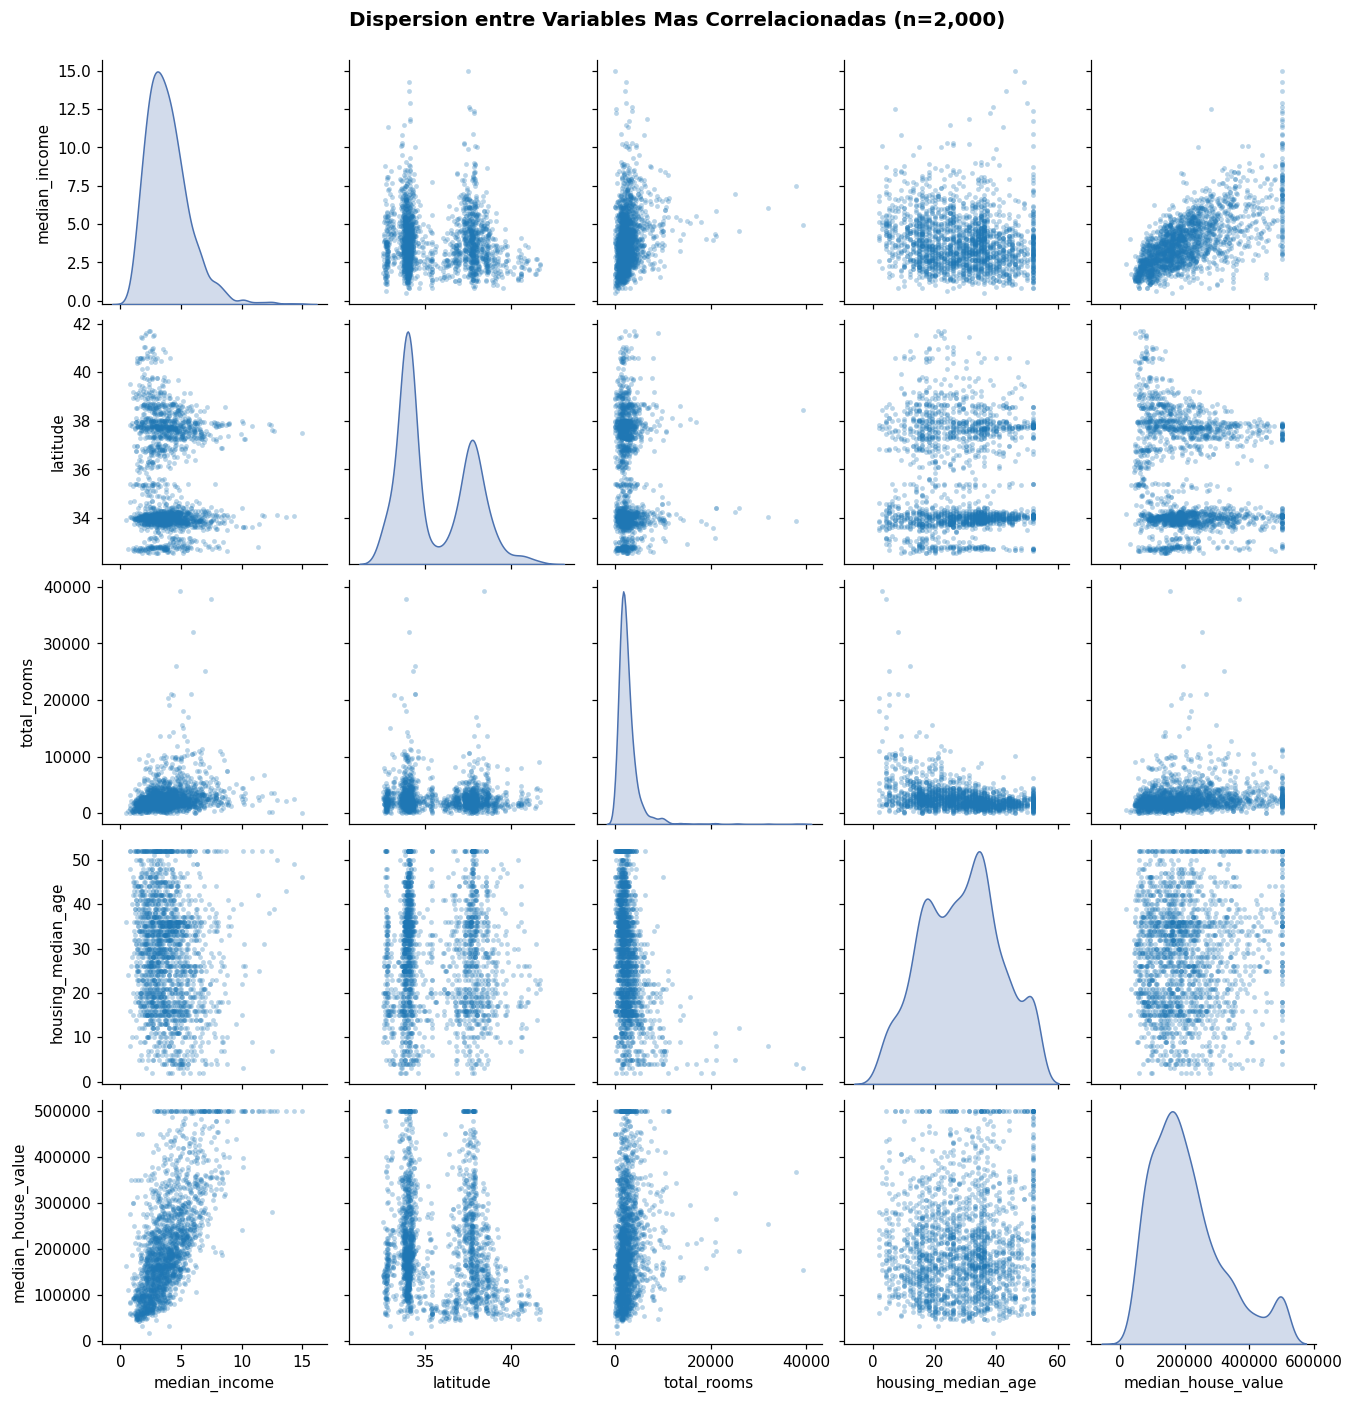

In [27]:
# Pairplot de las variables más relevantes (muestra para agilizar)
selected = top_features + ['median_house_value']
sample   = housing[selected].sample(2000, random_state=42)

g = sns.pairplot(
    sample, diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 10, 'linewidth': 0},
    diag_kws={'color': '#4C72B0', 'fill': True},
)
g.figure.suptitle(
    'Dispersion entre Variables Mas Correlacionadas (n=2,000)',
    y=1.02, fontsize=13, fontweight='bold',
)
plt.savefig(REPORTS_DIR / 'eda_pairplot.png', bbox_inches='tight', dpi=100)
plt.show()

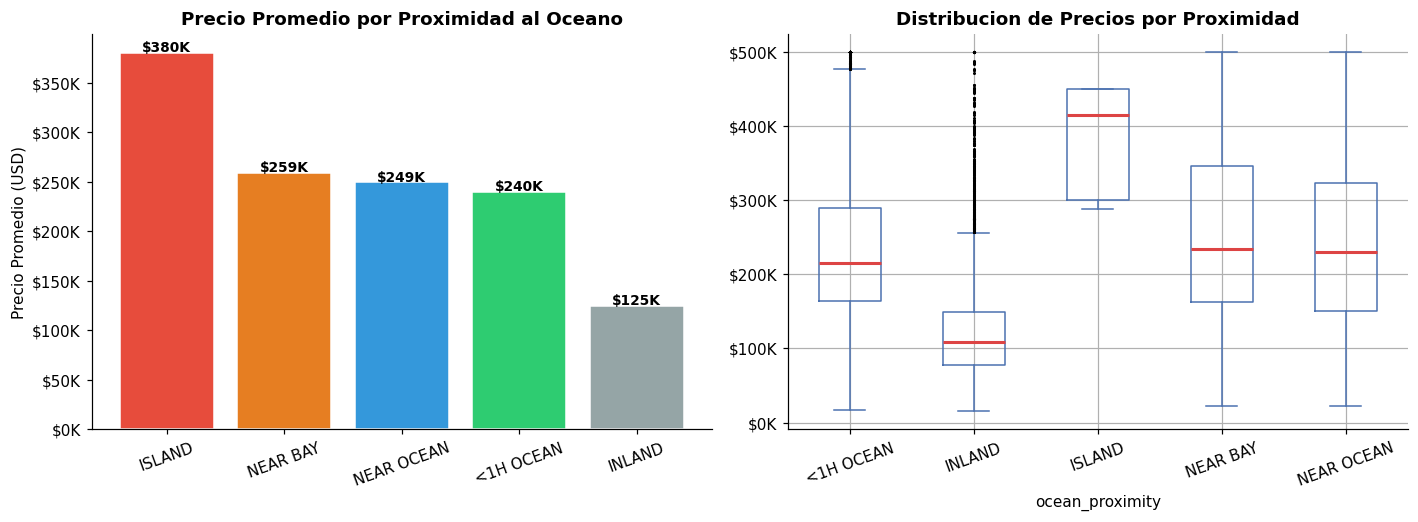

,Promedio,Mediana,Desv Est,N
ocean_proximity,,,,
ISLAND,380440.0000,414700.0000,80559.5618,5
NEAR BAY,259212.3118,233800.0000,122818.5371,2290
NEAR OCEAN,249433.9774,229450.0000,122477.1459,2658
<1H OCEAN,240084.2855,214850.0000,106124.2922,9136
INLAND,124805.3920,108500.0000,70007.9085,6551


In [28]:
ocp_stats = (
    housing.groupby('ocean_proximity')['median_house_value']
    .agg(['mean', 'median', 'std', 'count'])
    .sort_values('mean', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barplot de precio promedio
cats  = ocp_stats.index.tolist()
means = ocp_stats['mean'].values
c_map = {'ISLAND': '#e74c3c', 'NEAR BAY': '#e67e22', 'NEAR OCEAN': '#3498db',
         '<1H OCEAN': '#2ecc71', 'INLAND': '#95a5a6'}
cols  = [c_map.get(c, '#aaa') for c in cats]

bars = axes[0].bar(cats, means, color=cols, edgecolor='white')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[0].set_title('Precio Promedio por Proximidad al Oceano', fontweight='bold')
axes[0].set_ylabel('Precio Promedio (USD)')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'${val/1e3:.0f}K', ha='center', fontsize=9, fontweight='bold')

# Boxplot
housing.boxplot(
    column='median_house_value', by='ocean_proximity', ax=axes[1],
    boxprops=dict(color='#4C72B0'), medianprops=dict(color='#DD4444', linewidth=2),
    whiskerprops=dict(color='#4C72B0'), capprops=dict(color='#4C72B0'),
    flierprops=dict(marker='.', color='#aaa', markersize=2),
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].set_title('Distribucion de Precios por Proximidad', fontweight='bold')
axes[1].set_xlabel('ocean_proximity')
axes[1].tick_params(axis='x', rotation=20)
plt.suptitle('')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_ocean_proximity.png', bbox_inches='tight', dpi=120)
plt.show()

display(ocp_stats.rename(columns={'mean': 'Promedio', 'median': 'Mediana',
                                   'std': 'Desv Est', 'count': 'N'}))

In [29]:
# Guardar resúmenes finales
housing.describe(percentiles=[.05, .25, .5, .75, .95]).T.to_csv(
    REPORTS_DIR / 'eda_summary_stats.csv'
)

print('Reportes generados en reports/')
for f in sorted(REPORTS_DIR.iterdir()):
    kb = f.stat().st_size / 1024
    print(f'  {f.name:<45} ({kb:.1f} KB)')

Reportes generados en reports/
  .gitkeep                                      (0.0 KB)
  eda_correlaciones_target.png                  (38.1 KB)
  eda_correlation_matrix.csv                    (1.7 KB)
  eda_heatmap_correlacion.png                   (89.6 KB)
  eda_histogramas.png                           (105.2 KB)
  eda_mapa_geoespacial.png                      (336.7 KB)
  eda_ocean_proximity.png                       (60.5 KB)
  eda_pairplot.png                              (399.4 KB)
  eda_scatter_top_features.png                  (592.7 KB)
  eda_summary_stats.csv                         (1.0 KB)
  figures                                       (0.0 KB)
